# Config-Driven DKN Training

This notebook trains `GraphKalmanProcess` on the distance/angle constant-velocity scenario using a single `config_val` dictionary. It previews generated trajectories for each training run and saves both model weights and a matching JSON config file for later loading.

In [25]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
from pytorch_lightning.loggers import CSVLogger
from torch_geometric.loader import DataLoader

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

torch.set_default_dtype(torch.float32)

import utils.ConstantVelocityScenario as constant_velocity_scenario_module
importlib.reload(constant_velocity_scenario_module)

from utils.DistributedKalmanData import GraphDataset
from utils.DistributedKalmanNet import GraphKalmanProcess
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    create_distance_based_graph,
    get_trainer_accelerator,
    load_config,
    plot_generated_trajectories,
    plot_learning_curve,
    save_config,
    seed_everything,
)

## Configuration

Edit only `config_val` to change the scenario, training setup, save locations, or the initial state vector passed into both `GraphDataset` and `GraphKalmanProcess`.

In [26]:
config_path = REPO_ROOT / "configs" / "const_vel_scenario_configured.json"
config_val = load_config(config_path)
seed_everything(config_val["seed"])

num_nodes = config_val["num_nodes"]
state_dimension = config_val["state_dimension"]
time_steps = config_val["time_steps"]
time_delta = config_val["time_delta"]
process_noise_std = config_val["process_noise_std"]
measurement_noise_values = config_val["measurement_noise_values"]
x0 = np.array(config_val["x0"], dtype=float).reshape(state_dimension, 1)
node_positions = np.array(config_val["node_positions"], dtype=float)
trainer_accelerator = get_trainer_accelerator()
save_root = REPO_ROOT / config_val["save_root"]
log_root = REPO_ROOT / config_val["log_root"]

print(f"Loaded config from: {config_path}")
print(pd.Series(config_val))
print(f"\nTrainer accelerator: {trainer_accelerator}")
print(f"Initial state vector x0:\n{x0}")

Loaded config from: /Users/inega/Python/kalmanet2/distributedKNET/configs/const_vel_scenario_configured.json
batch_size                                                                 64
graph_seed                                                                 42
hidden_dim                                                                 64
k_neighbors                                                                 5
learn_edge_kalman                                                       False
learning_rate                                                         0.00001
log_root                                 models/const_vel_scenario_configured
max_epochs                                                                 40
measurement_noise_values                               [0.25, 0.5, 0.75, 1.0]
node_positions              [[37.45401188, 95.07143064], [73.19939418, 59....
num_nodes                                                                  10
num_trials                       

In [27]:
def plot_dkn_prediction_sample(graph, prediction, node_positions, title):
    """Plot one validation trajectory against the DKN prediction."""
    x_true = graph.y[:, 0, 0].cpu().numpy()
    y_true = graph.y[:, 2, 0].cpu().numpy()
    x_pred = prediction[:, 0]
    y_pred = prediction[:, 2]

    plt.figure(figsize=(7, 7))
    plt.plot(x_true, y_true, "b-", linewidth=2, label="True trajectory")
    plt.plot(x_pred, y_pred, "m--", linewidth=2, label="DKN prediction")
    plt.scatter(node_positions[:, 0], node_positions[:, 1], c="black", marker="s", s=40, label="Nodes")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()

## Train Models

For each measurement noise level, build the graph dataset on the configured graph, preview a few generated trajectories, train one DKN model, save the weight file, and save a matching JSON config file for later loading.

Training node positions:
[[37.45401188 95.07143064]
 [73.19939418 59.86584842]
 [15.60186404 15.59945203]
 [ 5.80836122 86.61761458]
 [60.11150117 70.80725778]
 [ 2.05844943 96.99098522]
 [83.24426408 21.23391107]
 [18.18249672 18.34045099]
 [30.4242243  52.47564316]
 [43.19450186 29.12291402]]

Training model for measurement noise r = 0.25


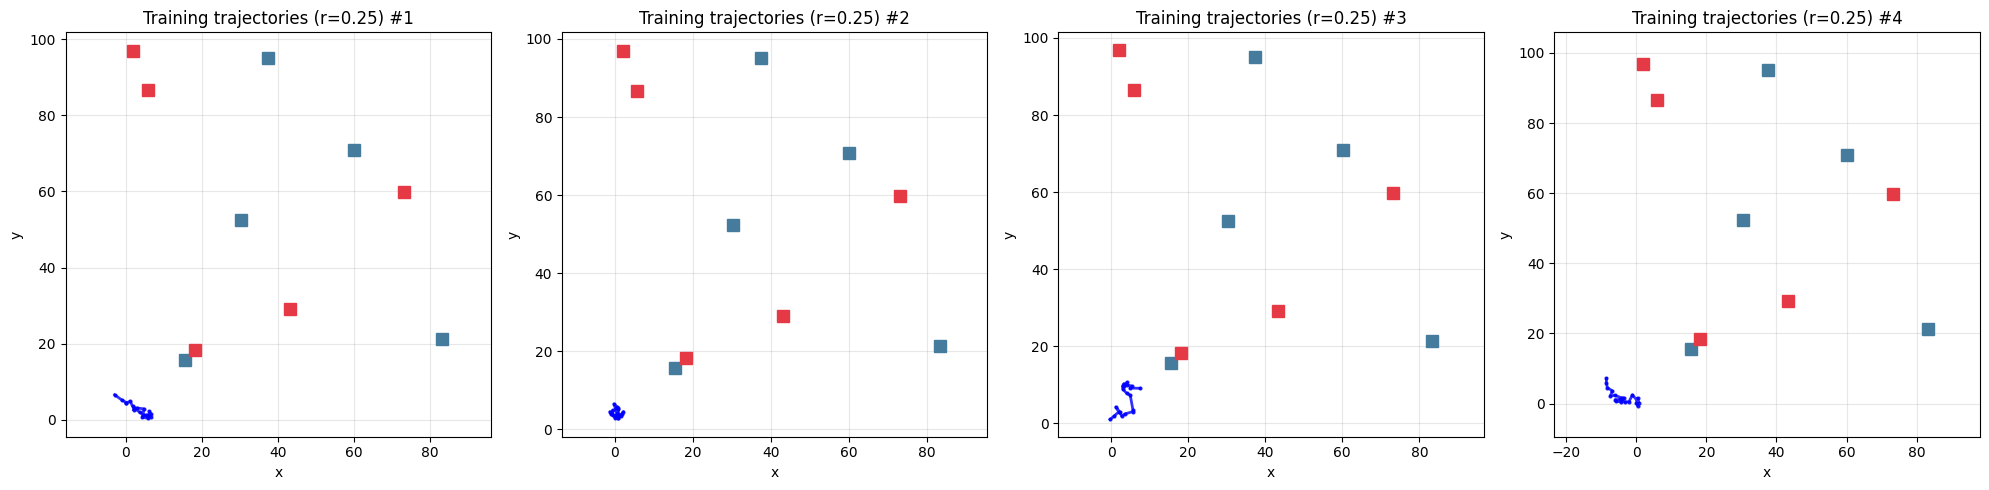

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario_configured/const_vel_scenario_r=0.25/0 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | gkf  | GraphKalmanFilter | 70.4 K | train
1 | loss | MSELoss           | 0      | train
---------------------------------------------------
70.4 K    Trainable params
0         Non-trainable params
70.4 K    Total params
0.282     Total estimated 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss:_epoch improved. New best score: 11.626


...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss:_epoch improved by 0.030 >= min_delta = 0.001. New best score: 6.116


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss:_epoch improved by 0.025 >= min_delta = 0.001. New best score: 6.091
`Trainer.fit` stopped: `max_epochs=40` reached.


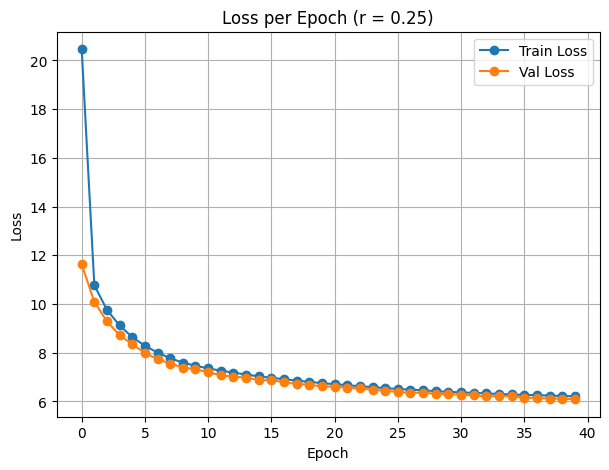

Saved learning curve: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario_configured/plots/learning_curve_r=0.25.png


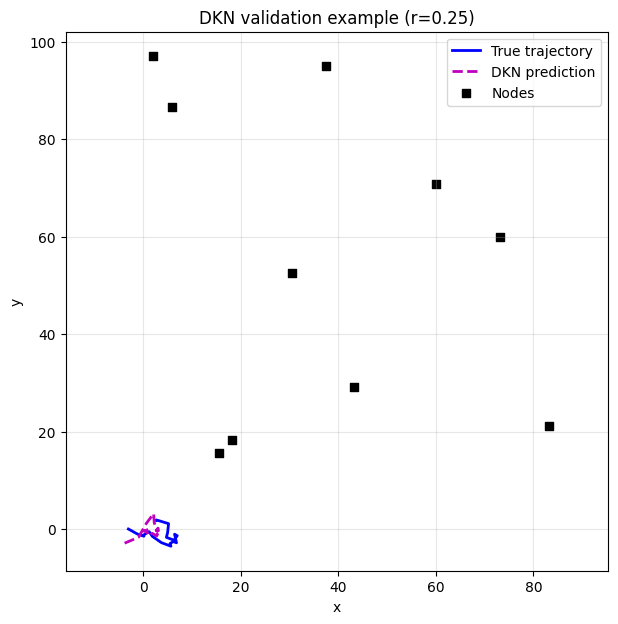

Saved model: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario_configured/DKN/const_vel_scenario_r=0.25.pth
Saved config: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario_configured/configs/const_vel_scenario_r=0.25.json

Training model for measurement noise r = 0.5


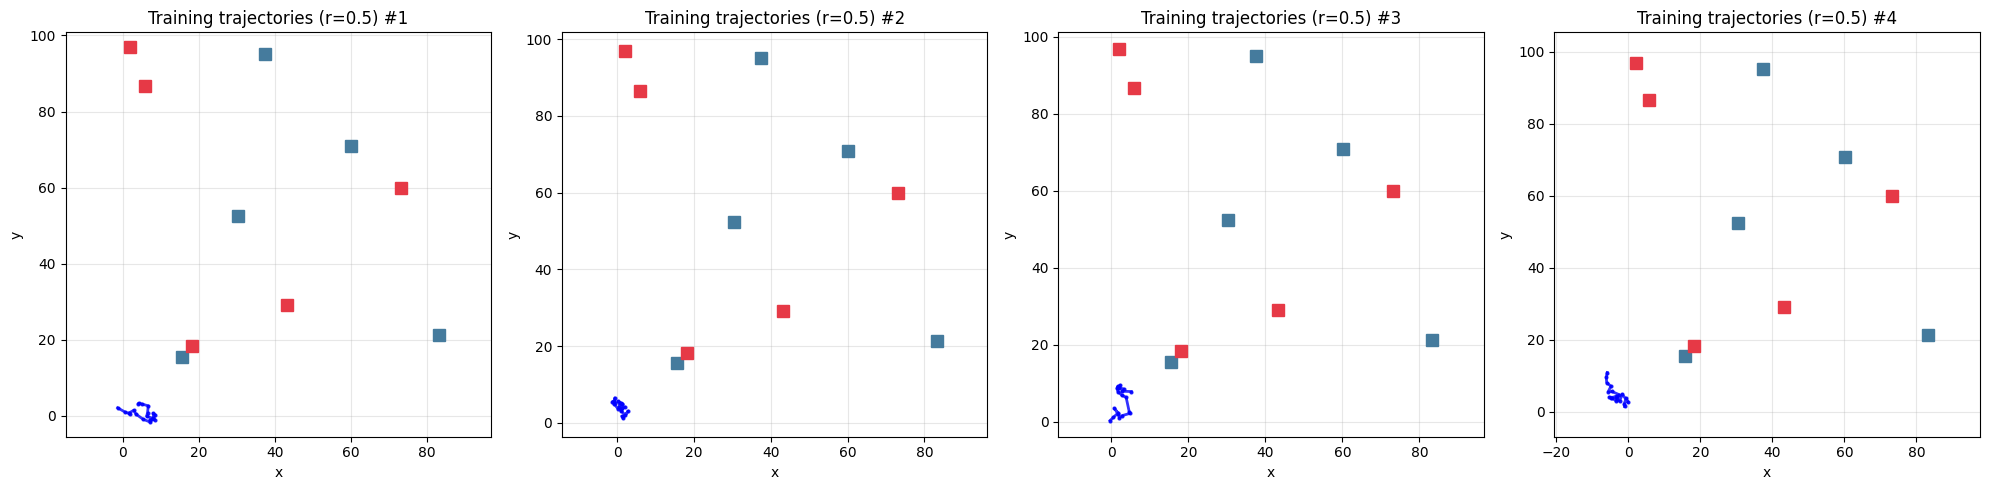

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario_configured/const_vel_scenario_r=0.5/0 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario_configured/const_vel_scenario_r=0.5/0/checkpoints exists and is not empty.

  | Name | Type              | Params | Mode 
---

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Metric val_loss:_epoch improved by 0.240 >= min_delta = 0.001. New best score: 7.482


Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss:_epoch improved by 0.132 >= min_delta = 0.001. New best score: 7.350


Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss:_epoch improved by 0.071 >= min_delta = 0.001. New best score: 7.279


In [ ]:
# Reload local modules so notebook runs always use the latest Python code.
import utils.DistributedKalmanData as distributed_kalman_data_module
import utils.DistributedKalmanNet as distributed_kalman_net_module
import utils.ConstantVelocityScenario as constant_velocity_scenario_module

importlib.reload(distributed_kalman_data_module)
importlib.reload(distributed_kalman_net_module)
importlib.reload(constant_velocity_scenario_module)

from utils.DistributedKalmanData import GraphDataset
from utils.DistributedKalmanNet import GraphKalmanProcess
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    create_distance_based_graph,
    plot_generated_trajectories,
    plot_learning_curve,
    save_config,
)

seed_everything(config_val["seed"])

f_system = ConstantVelocityModel(time_delta)
h_system = DistanceAngleObservation(node_positions)
adjacency_matrix = create_distance_based_graph(
    node_positions,
    k_neighbors=config_val["k_neighbors"],
    seed=config_val["graph_seed"],
)
node_types = h_system.node_classification[:, 0].cpu().numpy().astype(int)

model_dir = save_root / "DKN"
plot_dir = save_root / "plots"
config_dir = save_root / "configs"
for path in [model_dir, plot_dir, config_dir, log_root]:
    path.mkdir(parents=True, exist_ok=True)

print("Training node positions:")
print(node_positions)

for r_noise in measurement_noise_values:
    print(f"\nTraining model for measurement noise r = {r_noise}")
    r_array = r_noise * np.ones(num_nodes)

    train_dataset = GraphDataset(
        adjacency_matrix,
        f_system,
        h_system,
        process_noise_std,
        r_array,
        monte_carlo_simulations=config_val["train_sims"],
        time_steps=time_steps,
        n_expansions=1,
        x0=x0,
        state_dim=state_dimension,
    )
    val_dataset = GraphDataset(
        adjacency_matrix,
        f_system,
        h_system,
        process_noise_std,
        r_array,
        monte_carlo_simulations=config_val["val_sims"],
        time_steps=time_steps,
        n_expansions=1,
        x0=x0,
        state_dim=state_dimension,
    )

    sample_trajectories = [train_dataset[idx].y.cpu() for idx in range(min(config_val["preview_trajectories"], len(train_dataset)))]
    plot_generated_trajectories(
        node_positions,
        node_types,
        sample_trajectories,
        max_trajectories=config_val["preview_trajectories"],
        title_prefix=f"Training trajectories (r={r_noise})",
    )

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        batch_size=config_val["batch_size"],
        num_workers=0,
        pin_memory=False,
    )
    val_loader = DataLoader(
        val_dataset,
        shuffle=False,
        batch_size=config_val["batch_size"],
        num_workers=0,
        pin_memory=False,
    )

    kalman_process = GraphKalmanProcess(
        f_system,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=config_val["hidden_dim"],
        lr=config_val["learning_rate"],
        r_array=r_noise,
        learn_edge_kalman=config_val["learn_edge_kalman"],
        x0_scale=x0,
    ).to(torch.float32)

    logger = CSVLogger(str(log_root), name=f"const_vel_scenario_r={r_noise}", version="0")
    early_stopping = pl.callbacks.EarlyStopping(
        monitor="val_loss:_epoch",
        patience=5,
        verbose=True,
        mode="min",
        min_delta=0.001,
    )
    trainer = pl.Trainer(
        max_epochs=config_val["max_epochs"],
        accelerator=trainer_accelerator,
        devices=1,
        logger=logger,
        log_every_n_steps=5,
        callbacks=[early_stopping],
        gradient_clip_val=1,
    )
    trainer.fit(kalman_process, train_loader, val_loader)

    model_path = model_dir / f"const_vel_scenario_r={r_noise}.pth"
    config_path = config_dir / f"const_vel_scenario_r={r_noise}.json"
    torch.save(kalman_process.state_dict(), model_path)

    run_config = dict(config_val)
    run_config["measurement_noise"] = float(r_noise)
    run_config["graph_type"] = "distance_based_graph"
    run_config["model_path"] = str(model_path)
    run_config["config_path"] = str(config_path)
    save_config(run_config, config_path)

    plot_learning_curve(logger.log_dir, r_noise, save_dir=str(plot_dir))

    sample_graph = val_dataset[0]
    with torch.no_grad():
        sample_prediction = kalman_process(sample_graph).squeeze().cpu().numpy().mean(axis=1)
    plot_dkn_prediction_sample(sample_graph, sample_prediction, node_positions, title=f"DKN validation example (r={r_noise})")

    print(f"Saved model: {model_path}")
    print(f"Saved config: {config_path}")

## Later Load Example

Use the JSON config saved next to each weight file to reconstruct the scenario settings when loading a trained model later.

In [ ]:
example_r = measurement_noise_values[0]
example_config_path = save_root / "configs" / f"const_vel_scenario_r={example_r}.json"
example_model_path = save_root / "DKN" / f"const_vel_scenario_r={example_r}.pth"

print(f"Example config path: {example_config_path}")
print(f"Example model path:  {example_model_path}")

# Later, you can read the JSON config and rebuild the same graph/scenario before loading the weights.

Example config path: models/const_vel_scenario_configured/configs/const_vel_scenario_r=0.5.json
Example model path:  models/const_vel_scenario_configured/DKN/const_vel_scenario_r=0.5.pth
